In [39]:
from typing import Literal, Annotated, TypedDict
from pydantic import BaseModel
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import BaseMessage, HumanMessage, RemoveMessage
from langgraph.graph.message import add_messages
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import BaseStore, InMemoryStore
from langgraph.graph import StateGraph, START, END

In [40]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    decision: str

class DecisionState(BaseModel):
    aiMessage : Annotated[...,BaseMessage]
    decision : Literal["chat_node", "inventory_node", "__end__"]

In [41]:
llm = ChatOllama(model="llama3.1")
structured_llm = llm.with_structured_output(DecisionState)

In [42]:
def chat_node(state: State, config : RunnableConfig, store : BaseStore) -> State:
    messages = state.get("messages", None)
    user_id = config["configurable"]["user_id"]
    namespace = ("users", user_id)
    summary = store.get(namespace, key="summary")
    sys_prompt = f"""You are Egg, Squire to Ser Duncan The Tall. 
    Analyze the current conversation and respond to Ser Duncan.
    
    PAST MEMORY SUMMARY: {summary if summary else 'No past memory yet.'}
    
    RULES:
    1. If the current conversation length is getting long (more than 4 messages), output 'inventory_node' to summarize.
    2. Otherwise, output 'chat_node' to keep talking.
    """
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", sys_prompt),
        ("placeholder", "{messages}")
    ])
    
    chain = prompt | structured_llm
    decision_data = chain.invoke({"messages": messages})
    return {
        "messages": [AIMessage(content=decision_data.response)], 
        "decision": decision_data.decision
    }

In [43]:
def supervisor_node(state: State) -> Literal["chat_node", "inventory_node", "__end__"]:
    decision = state.get("decision", "chat_node")
    messages = state.get("messages", [])
    
    # Failsafe: if the LLM forgets to route to inventory but memory is huge, force it.
    if len(messages) >= 6 or decision == "inventory_node":
        return "inventory_node"
    elif decision == "__end__":
        return "__end__"
    return "chat_node"

In [44]:
def summarize_node(state: State, config: RunnableConfig, store: BaseStore) -> State:
    messages = state.get("messages", [])
    user_id = config["configurable"]["user_id"]
    summary_record = store.get(("users", user_id), key="summary")
    summary = summary_record.value.get("user_summary") if summary_record else ""
    
    # Stringify the messages to summarize
    chat_history = "\n".join([f"{m.type}: {m.content}" for m in messages])
    
    prompt = f"""Summarize the following conversation concisely (max 4 lines). 
    Incorporate this previous summary context: {summary}
    
    Conversation to summarize:
    {chat_history}
    """
    
    new_summary = llm.invoke(prompt).content
    
    # Save to long-term store
    store.put(("users", user_id), key="summary", value={"user_summary": new_summary})
    
    # Prune memory: Delete everything except the 2 most recent messages
    messages_to_del = messages[:-2] if len(messages) > 2 else []
    
    return {"messages": [RemoveMessage(id=m.id) for m in messages_to_del]}

In [ ]:
store = InMemoryStore()
checkpointer = InMemorySaver()
builder = StateGraph(State)

builder.add_node("chat", chat_node)
builder.add_node("inventory", summarize_node)

# User input feeds directly into the chat node now
builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat", 
    supervisor_node, 
    {
        "chat_node": END, # Pause and wait for next user input
        "inventory_node": "inventory",
        "__end__": END
    }
)

# After summarizing and pruning, wait for the next human input
builder.add_edge("inventory", END)
graph = builder.compile(checkpointer=checkpointer, store=store)

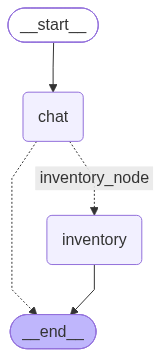

In [46]:
graph

In [47]:
# use the input from the user and use graph.invoke({"messages" : [HumanMessage(content="....")]}) inside a loop, it would be better 